In [1]:
# TASK 1 - Cleaning and visualizing the trip table

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from hashlib import sha256

# Loading of the parquet data file of the month of July 2025 
raw_data = pd.read_parquet("./yellow_tripdata_2022-07.parquet")

# Creating a copy of the raw parquet data to preserve the original data
cleaned_data = raw_data.copy()

# Converting the datetime columns from datetime64[us] to datetime64[ns]
cleaned_data["tpep_pickup_datetime"] = cleaned_data["tpep_pickup_datetime"].astype("datetime64[ns]")
cleaned_data["tpep_dropoff_datetime"] = cleaned_data["tpep_dropoff_datetime"].astype("datetime64[ns]")

# print(cleaned_data["tpep_pickup_datetime"].dtype)
print(f"Number of NaN values in tpep_pickup_datetime: {cleaned_data['tpep_pickup_datetime'].isna().sum()}") # verification of NaN from the time format conversion
print(f"Number of NaN values in tpep_dropoff_datetime: {cleaned_data['tpep_dropoff_datetime'].isna().sum()}") # verification of NaN from the time format conversion

# cleaned_data.info()



Number of NaN values in tpep_pickup_datetime: 0
Number of NaN values in tpep_dropoff_datetime: 0


In [2]:
# Removing trips where pickup time is not strictly before dropoff time.
cleaned_data = cleaned_data[cleaned_data["tpep_dropoff_datetime"] > cleaned_data["tpep_pickup_datetime"]]

# Removing of trips with non-positive distance
cleaned_data = cleaned_data[cleaned_data["trip_distance"] > 0]

# Robust quantile upper bound rule
Q1 = cleaned_data["trip_distance"].quantile(0.25)
Q3 = cleaned_data["trip_distance"].quantile(0.75)
IQR = Q3 - Q1

# Defining the upper bound
upper_bound = Q3 + 1.5 * IQR

# Removing extreme outliers
cleaned_data = cleaned_data[cleaned_data["trip_distance"] <= upper_bound]

# Removing negative fares and total amounts
cleaned_data = cleaned_data[(cleaned_data["fare_amount"] > 0) & (cleaned_data["total_amount"] > 0)]


cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 2717418 entries, 1 to 3174393
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64       


In [3]:
# Removing impossible passenger count - In Ireland, the maximum number of passengers allowed is 8, excluding the driver
cleaned_data = cleaned_data[cleaned_data["passenger_count"].between(1,8)]
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 2578248 entries, 1 to 3069198
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64       


In [4]:
# Calculating trip duration in minutes 
cleaned_data["trip_minutes"] = (cleaned_data["tpep_dropoff_datetime"] - cleaned_data["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Defining robust quantile upper bound rule for trip duration in minutes
Q1 = cleaned_data["trip_minutes"].quantile(0.25)
Q3 = cleaned_data["trip_minutes"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound definition
upper_bound = Q3 + 1.5 * IQR

# Removal of extreme minutes outliers
cleaned_data = cleaned_data[cleaned_data["trip_minutes"] <= upper_bound]



# Calculating speed in miles per hour
cleaned_data["speed_mph"] = (cleaned_data["trip_distance"] / cleaned_data["trip_minutes"]) * 60 

# Defining robust quantile upper bound rule for the speed
Q1 = cleaned_data["speed_mph"].quantile(0.25)
Q3 = cleaned_data["speed_mph"].quantile(0.75)
IQR = Q3 - Q1

# Defining upper bound
upper_bound = Q3 + 1.5 * IQR

# Removing extreme outliers
cleaned_data = cleaned_data[cleaned_data["speed_mph"] <= upper_bound]

# Converting the pick up date to datetime format
cleaned_data["pickup_datetime"] = cleaned_data["tpep_pickup_datetime"].astype("datetime64[ns]")

# Converting the pick up date to the date format
cleaned_data["pickup_date"] = cleaned_data["pickup_datetime"].dt.date

# Removing pickup dates that aren't strictly within the month of July 2022
cleaned_data = cleaned_data[(cleaned_data["pickup_datetime"].dt.year == 2022) & (cleaned_data["pickup_datetime"].dt.month == 7)]


# Converting the pick up date to the respective hour
cleaned_data["pickup_hour"] = cleaned_data["tpep_pickup_datetime"].dt.hour



# Resetting index and displaying information
cleaned_data = cleaned_data.reset_index(drop=True)
cleaned_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 2422334 entries, 0 to 2422333
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [5]:
# Data summary

raw_data_length = len(raw_data)
cleaned_data_length = len(cleaned_data)
percent_dropped = (raw_data_length - cleaned_data_length) / raw_data_length * 100
median_trip_minutes = cleaned_data["trip_minutes"].median()
median_speed_mph = cleaned_data["speed_mph"].median()

#For NYC Yellow Taxi data, the official mapping is:
# 0 = Flex Fare trip 
# 1 = Credit card
# 2 = Cash
# 3 = No charge
# 4 = Dispute
# 5 = Unknown
# 6 = Voided trip

share_card = (cleaned_data["payment_type"] == 1).mean()
share_cash = (cleaned_data["payment_type"] == 2).mean()

summary = pd.DataFrame({
    "Metric": ["Raw Data Length", "Cleaned Data Length", "Percent Dropped", "Median Trip Minutes", "Median Speed MPH", "Share Cash", "Share Card"],
    "Value": [raw_data_length, cleaned_data_length, percent_dropped, median_trip_minutes, median_speed_mph, share_cash, share_card]
})

# Rounding the standard forms of values to 3 decimal places
summary["Value"] = summary["Value"].apply(
    lambda x: int(x) if x >= 1 else round(x, 3)
)

# Creating the output folder
os.makedirs("./outputs", exist_ok=True)

# Storing the csv file to the outputs folder
summary.to_csv("outputs/task1_summary.csv", index=False)

count    2422334.000
mean          10.488
std            3.628
min            0.022
25%            7.897
50%           10.077
75%           12.698
max           20.819
Name: speed_mph, dtype: float64


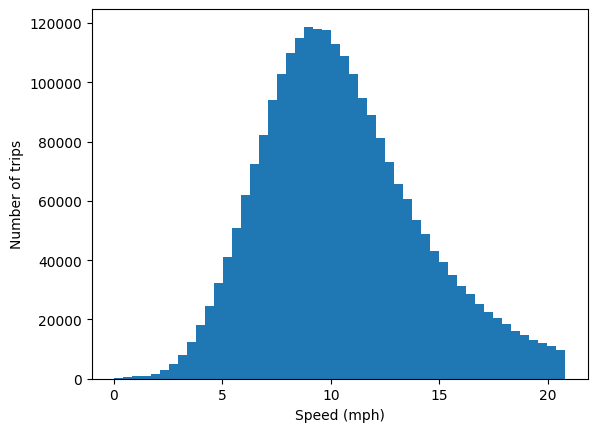

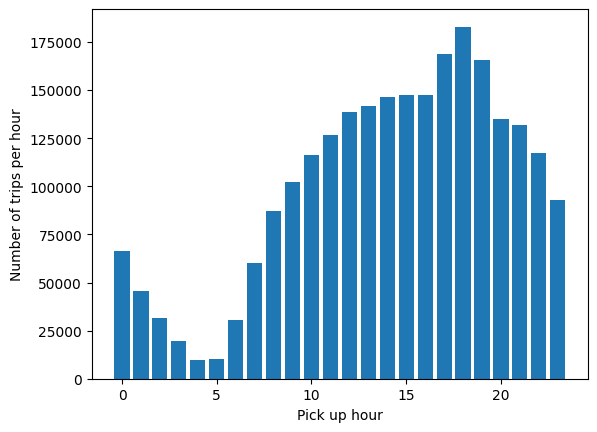

In [6]:
# Visualization of the speed distribution
print(cleaned_data["speed_mph"].describe().round(3))
plt.hist(cleaned_data["speed_mph"].round(3), bins=50)
plt.xlabel("Speed (mph)")
plt.ylabel("Number of trips")
plt.savefig("./outputs/task1_speed_hist.png")
plt.show()

# Visualization of the total number of trip for each hour
hour_counts = cleaned_data["pickup_hour"].value_counts().sort_index()
plt.bar(hour_counts.index, hour_counts.values)
plt.xlabel("Pick up hour")
plt.ylabel("Number of trips per hour")
plt.savefig("./outputs/task1_hourly_volume.png")
plt.show()

In [7]:
 # TASK2 - Enriching the trip table with borough-to-borough flow and route concentration
 
# Loading the lookup zones
lookup_data = pd.read_csv("./taxi_zone_lookup.csv")

# Joining the trip table with the lookup zones on the pickup location ID
trips_enriched = cleaned_data.merge(lookup_data, left_on="PULocationID", right_on="LocationID", how="left")

# Renaming the joined columns to easily identify which it corresponds to, as well as to prevent overwriting of the second join
trips_enriched = trips_enriched.rename(columns={"Borough": "PU_Borough", "Zone": "PU_Zone", "service_zone": "PU_service_zone"})

# Joining the trip table with the lookup zones on the dropoff location ID
trips_enriched = trips_enriched.merge(lookup_data, left_on="DOLocationID", right_on="LocationID", how="left")

# Renaming the joined columns to easily identify which it corresponds to
trips_enriched = trips_enriched.rename(columns={"Borough": "DO_Borough", "Zone": "DO_Zone", "service_zone": "DO_service_zone"
})

# Dropping unnecessary columns
trips_enriched = trips_enriched.drop(columns=["LocationID_y", "LocationID_x"])

trips_enriched.info()

<class 'pandas.DataFrame'>
RangeIndex: 2422334 entries, 0 to 2422333
Data columns (total 30 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [8]:
# OD Trip table

# Grouping to build the OD table
od_table = trips_enriched.groupby(["PU_Borough", "DO_Borough"]).agg(trip_count=("trip_minutes", "count"), median_total_amount=("total_amount", "median"), p90_trip_minutes=("trip_minutes", lambda x: x.quantile(0.9).round(3))).reset_index()

od_table

,PU_Borough,DO_Borough,trip_count,median_total_amount,p90_trip_minutes
0,Bronx,Bronx,1160,17.825,24.002
1,Bronx,Manhattan,376,15.800,25.767
2,Bronx,Queens,8,25.350,19.808
3,Bronx,Unknown,4,22.300,13.410
4,Brooklyn,Brooklyn,6413,13.570,22.767
5,Brooklyn,Manhattan,3456,22.560,26.200
6,Brooklyn,Queens,289,18.360,25.563
7,Brooklyn,Staten Island,1,27.760,11.950
8,Brooklyn,Unknown,10,20.430,26.180
9,EWR,EWR,86,111.850,2.017


In [9]:
# Computating the destination shares and the Herfindahl–Hirschman Index (HHI)
od_table["destination_share"] = od_table["trip_count"]/od_table.groupby("PU_Borough")["trip_count"].transform("sum")

hhi = od_table.groupby("PU_Borough")["destination_share"].apply(lambda x: (x**2).sum()).reset_index(name="HHI")

od_table = od_table.merge(hhi, on="PU_Borough", how="left")

od_table = od_table.rename(columns={"HHI": "HH_index"})

od_table.head()


,PU_Borough,DO_Borough,trip_count,median_total_amount,p90_trip_minutes,destination_share,HH_index
0,Bronx,Bronx,1160,17.825,24.002,0.749354,0.620562
1,Bronx,Manhattan,376,15.800,25.767,0.242894,0.620562
2,Bronx,Queens,8,25.350,19.808,0.005168,0.620562
3,Bronx,Unknown,4,22.300,13.410,0.002584,0.620562
4,Brooklyn,Brooklyn,6413,13.570,22.767,0.630642,0.514021


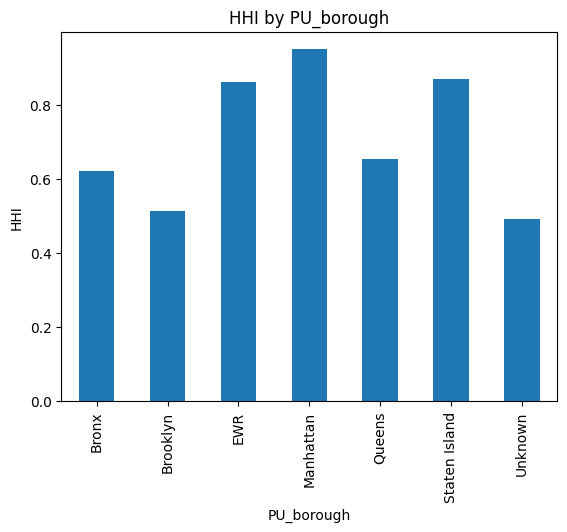

In [10]:
# Calculating top 3 DO_borough by trip count, including the destination share and the PU_borough's HHI 
top_routes = od_table.groupby(["PU_Borough", "HH_index"]).apply(lambda x: x.nlargest(3, "trip_count")).reset_index(drop=True)

# Saving to the output folder as csv file
top_routes.to_csv("outputs/task2_top_routes.csv", index=False)

# Plotting the bar chart of HHI by PU_borough
hhi.plot(kind="bar", x="PU_Borough", y="HHI", legend=False)
plt.title("HHI by PU_borough")
plt.xlabel("PU_borough")
plt.ylabel("HHI")
plt.savefig("outputs/task2_hhi.png")
plt.show()


In [11]:
# Task 3 - Computation of Weather join quality and rain penalty (external data join)

# Loading the weather data
raw_weather_data = pd.read_csv("./nycentral_city_weather_data.csv")

# Creating a copy of the raw weather data to preserve the original data
weather_daily = raw_weather_data.copy()

# Selecting necessary columns
weather_daily = weather_daily[["DATE", "PRCP", "TMAX", "TMIN"]]

# Converting DATE to datetime format
weather_daily["DATETIME"] = weather_daily["DATE"].astype("datetime64[ns]")

# Extracting the date
weather_daily["DATE"] = weather_daily["DATETIME"].dt.date

# Converting PRCP from inches to millimeters
weather_daily["PRCP"] = weather_daily["PRCP"] * 25.4

# Converting Temperature from Fahrenheit to Celcius
temp_cols = ["TMAX", "TMIN"]
weather_daily[temp_cols] = ((weather_daily[temp_cols] - 32) * 5/9).round(3)

# Renaming columns to their appropriate name
weather_daily = weather_daily.rename(columns={"DATETIME":"datetime", "DATE": "date", "PRCP": "prcp_mm", "TMAX": "tmax_c", "TMIN": "tmin_c"})

# Joining of the taxi trip table with the weather data on the date
trips_weather_enriched = trips_enriched.merge(weather_daily, left_on="pickup_date", right_on="date", how="left")

# Checking the missing value counts
trips_weather_enriched.isna().sum()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag           0
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
airport_fee                  0
trip_minutes                 0
speed_mph                    0
pickup_datetime              0
pickup_date                  0
pickup_hour                  0
PU_Borough                 193
PU_Zone                  20594
PU_service_zone          20787
DO_Borough                 919
DO_Zone                  13589
DO_service_zone          14508
date                         0
prcp_mm                      0
tmax_c  

In [12]:
# Creating outputs/task3_weather_join_quality.csv containing: taxi_days, weather_days, join_coverage (percent of taxi_days that found weather), and a comma-separated list of missing_weather_days.

taxi_days = set(trips_enriched["pickup_date"])
weather_days = set(weather_daily["date"])
join_coverage = len(taxi_days & weather_days) / len(taxi_days) * 100
missing_weather_days = sorted(taxi_days - weather_days)

task3_join_quality = pd.DataFrame([{"taxi_days": len(taxi_days), "weather_days": len(weather_days), "join_coverage": join_coverage, "missing_weather_days": ",".join(str(d.date()) for d in missing_weather_days) if missing_weather_days else "0"}])

# Storing it as a csv to the outputs folder
task3_join_quality.to_csv("outputs/task3_join_quality.csv", index=False)

In [ ]:

# Defining rainy_day using a data-derived threshold

# Finding the threshold. Days will be considered rainy if the precipitation for the day goes above the 75th percentile of days with precipitation above 0

# Extracting days with non-zero precipitation values
rainy_days = trips_weather_enriched[trips_weather_enriched["prcp_mm"] > 0]

threshold = rainy_days["prcp_mm"].quantile(.75)

# A day is only considered rainy where precipitation is greater than or equal to the 75th percentile of all non-zero daily precipitation values in the month
trips_weather_enriched["rainy_day"] = trips_weather_enriched["prcp_mm"] >= threshold

no_rain = trips_weather_enriched[~trips_weather_enriched["rainy_day"]]
yes_rain = trips_weather_enriched[trips_weather_enriched["rainy_day"]]

print("The median trip duration in minutes for trips on days without rain is:", no_rain["trip_minutes"].median().round(3))

print("The median paid amount for trips on days without rain is:", no_rain["total_amount"].median().round(3))

print("The median distance covered on days without rain is:", no_rain["trip_distance"].median().round(3))


print("The median trip duration in minutes for trips on days with rain is:", yes_rain["trip_minutes"].median().round(3))

print("The median paid amount for trips on days with rain is:", yes_rain["total_amount"].median().round(3))

print("The median distance covered on days with rain is:", yes_rain["trip_distance"].median().round(3))

print("""
Interpretation:
The median paid amount and median trip duration are nearly the same for both rainy and non-rainy 
days. The amount paid differs by only $0.14 and the duration by approximately 0.18 minutes, which 
suggests that rainfall doesn't significantly impact the cost or duration of taxi trips.
""")

The median trip duration in minutes for trips on days without rain is: 10.533
The median paid amount for trips on days without rain is: 14.3
The median distance covered on days without rain is: 1.66
The median trip duration in minutes for trips on days with rain is: 10.35
The median paid amount for trips on days with rain is: 14.16
The median distance covered on days with rain is: 1.65

Interpretation:
The median paid amount and median trip duration are nearly the same for both rainy and non-rainy 
days. The amount paid differs by only $0.14 and the duration by approximately 0.18 minutes, which 
suggests that rainfall doesn't significantly impact the cost or duration of taxi trips.



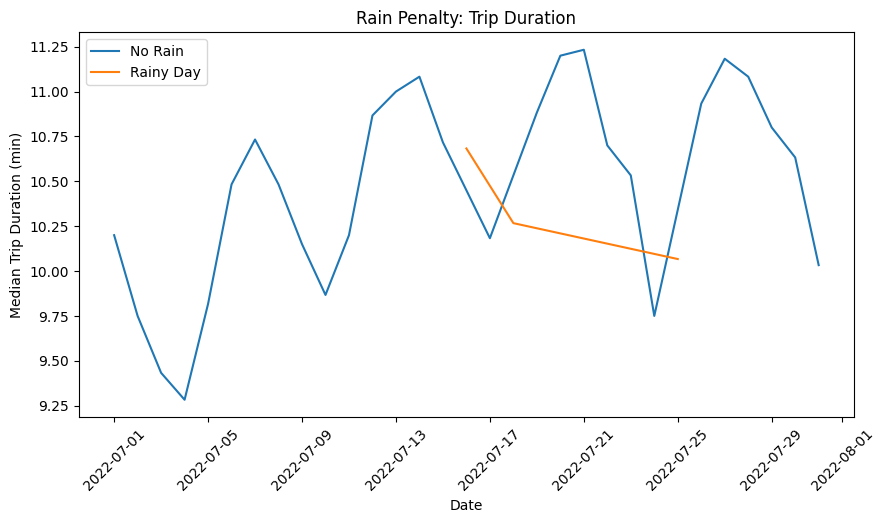

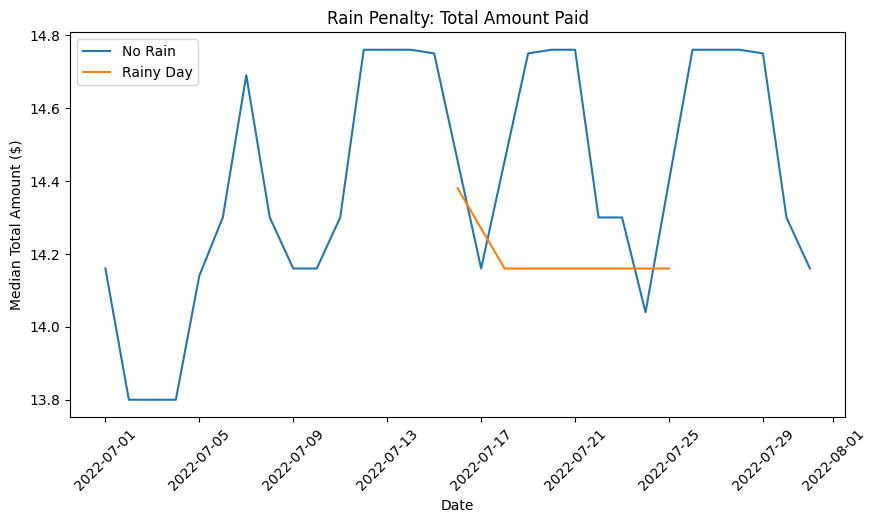

In [14]:
daily_medians = trips_weather_enriched.groupby(["date", "rainy_day"]).agg(median_trip_minutes=("trip_minutes", "median"), median_total_amount=("total_amount", "median")).reset_index()

daily_medians["median_trip_minutes"] = daily_medians["median_trip_minutes"].round(3)
daily_medians["median_total_amount"] = daily_medians["median_total_amount"].round(3)

# daily_medians
no_rain_group = daily_medians[daily_medians["rainy_day"] == False]
yes_rain_group = daily_medians[daily_medians["rainy_day"] == True]

# Plotting median trip duration for rainy and non-rainy days
plt.figure(figsize=(10,5))
plt.plot(no_rain_group["date"], no_rain_group["median_trip_minutes"], label="No Rain")
plt.plot(yes_rain_group["date"], yes_rain_group["median_trip_minutes"], label="Rainy Day")

# Labels and legend
plt.xlabel("Date")
plt.ylabel("Median Trip Duration (min)")
plt.title("Rain Penalty: Trip Duration")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("outputs/task3_rain_duration.png") # Saving the plot
plt.show()

# Plotting median total amount for rainy and non-rainy days
plt.figure(figsize=(10,5))
plt.plot(no_rain_group["date"], no_rain_group["median_total_amount"], label="No Rain")
plt.plot(yes_rain_group["date"], yes_rain_group["median_total_amount"], label="Rainy Day")

# Labels and legend
plt.xlabel("Date")
plt.ylabel("Median Total Amount ($)")
plt.title("Rain Penalty: Total Amount Paid")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("outputs/task3_rain_amount.png")  # Saving the plot

plt.show()


In [15]:
# TASK 4

# Grouping trips by pickup_hour and PU_Borough and computing the median speed_mph and the median absolute deviation (MAD). Use these to compute a robust z-score: rz = (x − median) / (1.4826 × MAD).

hour_borough_group = trips_weather_enriched.groupby(["pickup_hour", "PU_Borough"])["speed_mph"].agg(median_speed_mph="median", median_absolute_deviation=lambda x: np.median(np.abs(x - np.median(x))), group_size = "count").reset_index()

# Merging these group stats back into the main travel data
trips_weather_enriched_mad = trips_weather_enriched.merge(hour_borough_group, on=["pickup_hour", "PU_Borough"], how="left")

# The minimum group size was chosen as N ~= 41 since it's the 25th percentile of group counts, ensuring that the smallest quartile of groups is ignored while retaining the majority of observations for stable MAD estimation
N = int(hour_borough_group["group_size"].quantile(0.25))

# Defining a function to compute the robust z-score by filtering out groups with size < N and MAD = 0
def compute_rz(row):
    if row["group_size"] < N:
        return np.nan
    if row["median_absolute_deviation"] == 0:
        return np.nan
    return (row["speed_mph"] - row["median_speed_mph"]) / (1.4826 * row["median_absolute_deviation"])

# Computing the robust z-score
trips_weather_enriched_mad["rz_score"] = trips_weather_enriched_mad.apply(compute_rz, axis=1)

print(trips_weather_enriched_mad["rz_score"].describe().round(3))



count    2421852.000
mean           0.098
std            1.058
min           -4.374
25%           -0.635
50%            0.000
75%            0.724
max            4.107
Name: rz_score, dtype: float64


In [16]:
# Given that the z-scores produce a normal distribution bell curve ranging from 4.11 to 4.37, I'll be using the IQR method to inform my decision on the threshold that'll be used for identifying extreme outliers

# Defining upper bound rule for the rz score
Q1 = trips_weather_enriched_mad["rz_score"].quantile(0.25)
Q3 = trips_weather_enriched_mad["rz_score"].quantile(0.75)
IQR = Q3 - Q1

# Upper bound definition
upper_bound = Q3 + 1.5 * IQR
print("The threshold using the IQR upper_bound method is: ", upper_bound)

# From the calculation, the upper bound is approximately 2.8. To ensure that only true anomalies will be flagged, I'll be using 3.5

rz_threshold = 3.5

# Flagging anomalies
trips_weather_enriched_mad["is_anomaly"] = trips_weather_enriched_mad["rz_score"].abs() > rz_threshold

anomalies = trips_weather_enriched_mad[trips_weather_enriched_mad["is_anomaly"]]

anomalies = anomalies[["tpep_pickup_datetime", "tpep_dropoff_datetime", "PU_Borough", "DO_Borough", "speed_mph", "rz_score", "total_amount"]]

# Saving as a csv to the outputs folder
anomalies.to_csv("outputs/task4_anomalies.csv", index=False)


The threshold using the IQR upper_bound method is:  2.762848991487358


C:\Users\nedyk\AppData\Local\Temp\ipykernel_29448\2884313153.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("outputs/task4_anomaly_scatter.png", dpi=300)
c:\USERS\NEDYK\NCI_WORKS\25152211-DATA-WRANGLING\.VENV\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


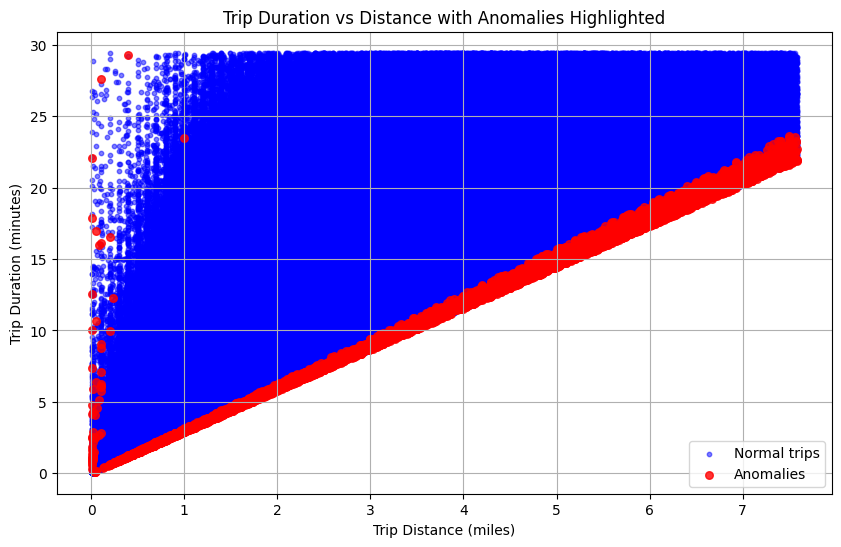

In [17]:
# Plotting the scatter plot
plt.figure(figsize=(10, 6))

# Normal trips
plt.scatter(trips_weather_enriched_mad.loc[~trips_weather_enriched_mad["is_anomaly"], "trip_distance"], trips_weather_enriched_mad.loc[~trips_weather_enriched_mad["is_anomaly"], "trip_minutes"], s=10, color="blue", alpha=0.5, label="Normal trips")

# Anomalies
plt.scatter(trips_weather_enriched_mad.loc[trips_weather_enriched_mad["is_anomaly"], "trip_distance"],trips_weather_enriched_mad.loc[trips_weather_enriched_mad["is_anomaly"], "trip_minutes"],s=30, color="red",alpha=0.8,label="Anomalies")

# Labels and legend
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Trip Duration (minutes)")
plt.title("Trip Duration vs Distance with Anomalies Highlighted")
plt.legend()
plt.grid(True)

# Saving the figure
plt.savefig("outputs/task4_anomaly_scatter.png", dpi=300)
plt.show()

In [18]:
# Task 5 – Deterministic sample and unique fingerprint (anti-copy)

STUDENT_ID = "25252211" 
SALT = ""
OUTPUT_FILE = "outputs/task5_fingerprint.txt"

# Handling the case where the cleaned dataset has less than 2000 rows
clean_rows = len(trips_weather_enriched_mad)
if clean_rows < 2000:
    raise ValueError(f"trips_clean has only {clean_rows} rows; cannot sample 2000 rows.")

# Computing seed
seed_hex = sha256((STUDENT_ID + SALT).encode()).hexdigest()[:8]
seed = int(seed_hex, 16)

# Sampling the 2000 rows deterministically
rng = np.random.default_rng(seed)
sample_indices = rng.choice(trips_weather_enriched_mad.index, size=2000, replace=False)
sampled = trips_weather_enriched_mad.loc[sample_indices, ["trip_minutes", "trip_distance", "total_amount", "speed_mph"]]

# Rounding to 3 decimals
sampled_rounded = sampled.round(3)

# Column means and standard deviations
means = sampled_rounded.mean().to_numpy()
stds = sampled_rounded.std(ddof=0).to_numpy()

# Computing sig
sig = np.dot(means, [1, 10, 100, 1000]) + np.dot(stds, [2, 20, 200, 2000])

# Computing fingerprint
fingerprint = sha256(str(sig).encode()).hexdigest()

# Writing to the output file
with open(OUTPUT_FILE, "w") as f:
    f.write(f"STUDENT_ID: {STUDENT_ID}\n")
    f.write(f"seed: {seed}\n")
    f.write(f"clean_rows: {clean_rows}\n")
    f.write(f"sig: {sig}\n")
    f.write(f"fingerprint: {fingerprint}\n")

print(f"Fingerprint written to {OUTPUT_FILE}")

Fingerprint written to outputs/task5_fingerprint.txt
